# 01 - Burgers' Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t + u u_x = \nu u_{xx}$, $\nu = 0.01/\pi$

**IC:** $u(x,0) = -\sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

---
### Experiments
1. Vanilla PINN - clean dense data
2. Vanilla PINN - noisy sparse data (ε=0.1, N_ic=20)
3. AC-PINN - clean dense data
4. AC-PINN - noisy sparse data (ε=0.1, N_ic=20)

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE      = 'burgers'
LAYERS   = [2, 64, 64, 64, 64, 64, 1]
EPOCHS   = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS  = '../results/burgers/'
FIGURES  = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

BurgersFDM solved in 0.6802s


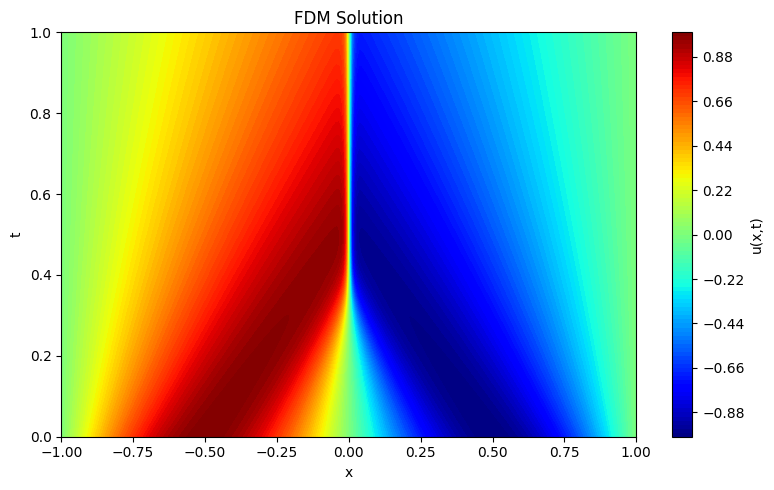

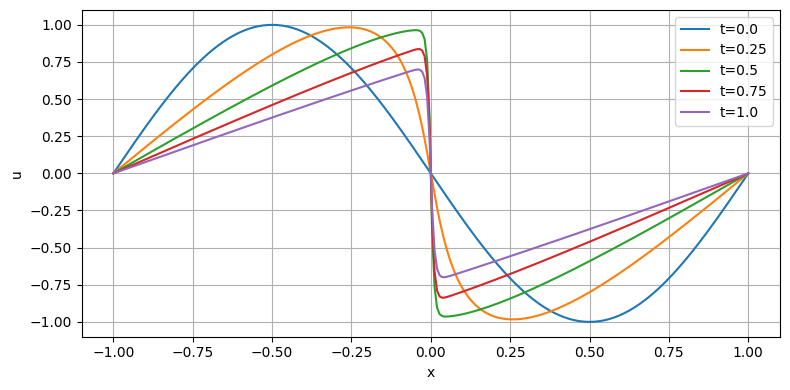

FDM runtime: 0.6802s


In [2]:
fdm = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
fdm.plot_solution()
fdm.plot_time_slices()
print(f'FDM runtime: {fdm.runtime:.4f}s')

## Section 2 - Data Conditions

In [3]:
# Clean dense
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
# Noisy sparse
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)

print('Data conditions ready')
print(f'  Clean dense  : N_ic={data_clean_dense["x_ic"].shape[0]}')
print(f'  Noisy sparse : N_ic={data_noisy_sparse["x_ic"].shape[0]}, eps=0.1')

Data conditions ready
  Clean dense  : N_ic=1000
  Noisy sparse : N_ic=20, eps=0.1


## Section 3 - Experiment 1: Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Burgers | Vanilla Clean | Epoch     0/10000] Total: 0.503524 | IC: 0.365687 | BC: 0.107761 | PDE: 0.006015


[Burgers | Vanilla Clean | Epoch  1000/10000] Total: 0.110548 | IC: 0.092263 | BC: 0.000602 | PDE: 0.003537


[Burgers | Vanilla Clean | Epoch  2000/10000] Total: 0.072101 | IC: 0.055361 | BC: 0.000179 | PDE: 0.003312


[Burgers | Vanilla Clean | Epoch  3000/10000] Total: 0.191603 | IC: 0.156860 | BC: 0.000470 | PDE: 0.006855


...

[Burgers | Vanilla Clean | Epoch  6000/10000] Total: 0.014484 | IC: 0.010115 | BC: 0.000033 | PDE: 0.000867


[Burgers | Vanilla Clean | Epoch  7000/10000] Total: 0.009108 | IC: 0.005788 | BC: 0.000017 | PDE: 0.000661


[Burgers | Vanilla Clean | Epoch  8000/10000] Total: 0.006109 | IC: 0.003726 | BC: 0.000011 | PDE: 0.000474


[Burgers | Vanilla Clean | Epoch  9000/10000] Total: 0.004013 | IC: 0.002444 | BC: 0.000006 | PDE: 0.000313



Training complete in 163.37s


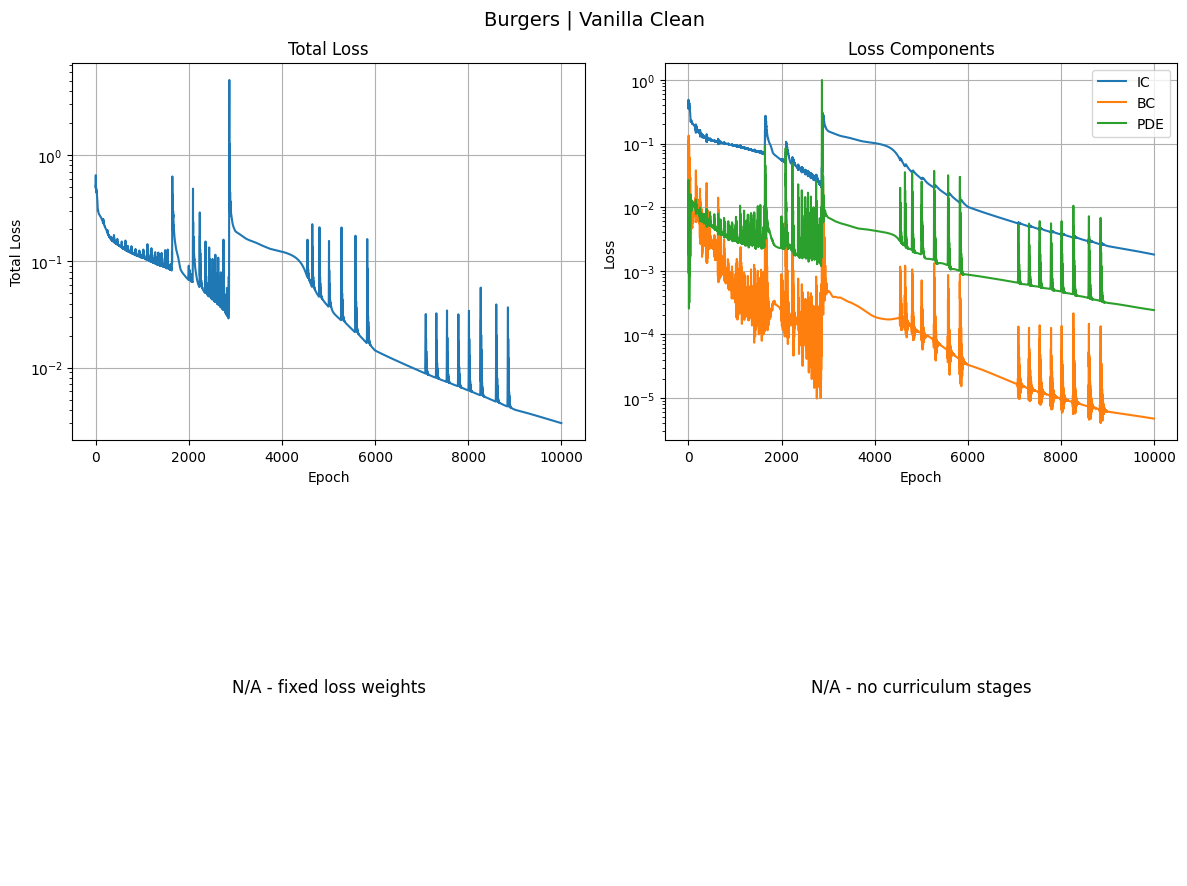

Saved: ../figures/burgers/vanilla_clean_training.png
Saved: ../figures/burgers/vanilla_clean_training.csv


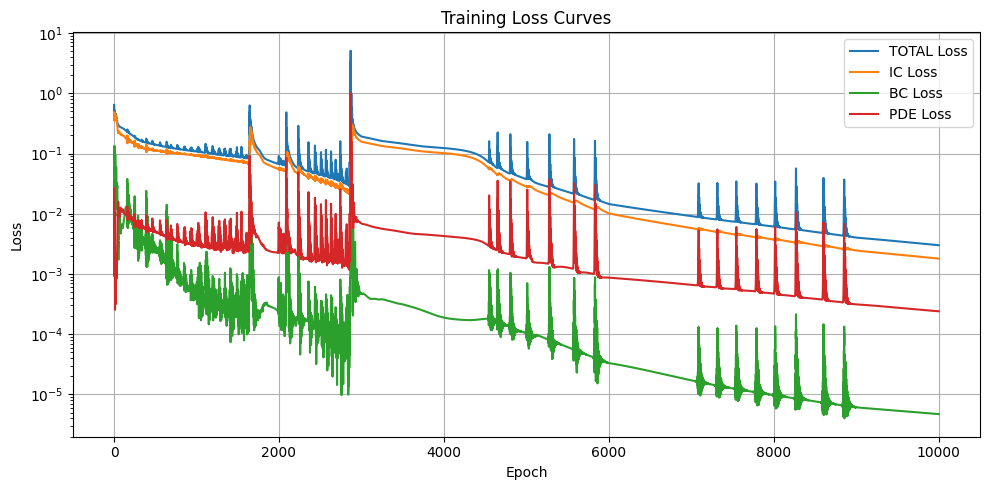

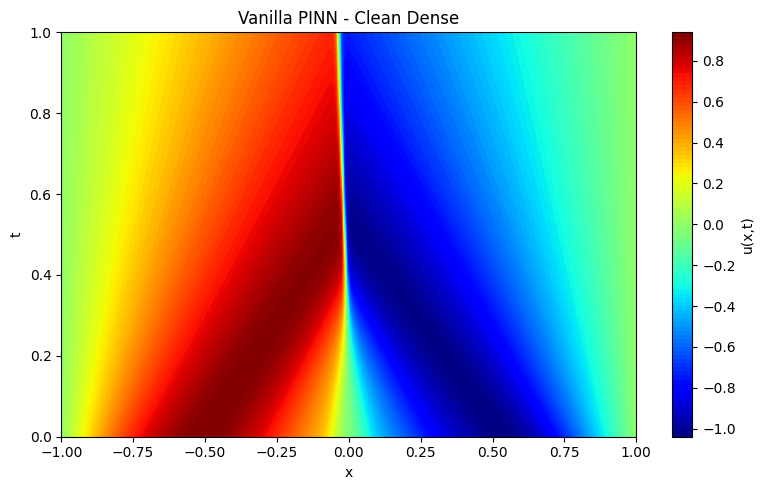

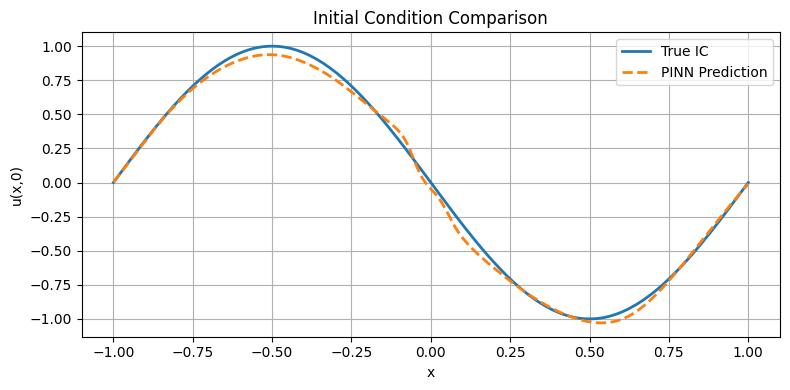

Saved: ../results/burgers/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Burgers | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS + 'vanilla_clean_history.npy')

## Section 4 - Experiment 2: Vanilla PINN, Noisy Sparse

[Burgers | Vanilla Noisy | Epoch     0/10000] Total: 1.520764 | IC: 1.014184 | BC: 0.432268 | PDE: 0.014862


[Burgers | Vanilla Noisy | Epoch  1000/10000] Total: 0.136463 | IC: 0.097682 | BC: 0.017031 | PDE: 0.004350


[Burgers | Vanilla Noisy | Epoch  2000/10000] Total: 0.071777 | IC: 0.046826 | BC: 0.015001 | PDE: 0.001990


[Burgers | Vanilla Noisy | Epoch  3000/10000] Total: 0.061059 | IC: 0.032510 | BC: 0.014546 | PDE: 0.002801


[Burgers | Vanilla Noisy | Epoch  4000/10000] Total: 0.048115 | IC: 0.026313 | BC: 0.014385 | PDE: 0.001484


...

[Burgers | Vanilla Noisy | Epoch  6000/10000] Total: 0.031564 | IC: 0.013810 | BC: 0.013926 | PDE: 0.000766


[Burgers | Vanilla Noisy | Epoch  7000/10000] Total: 0.029800 | IC: 0.012337 | BC: 0.013852 | PDE: 0.000722


[Burgers | Vanilla Noisy | Epoch  8000/10000] Total: 0.027003 | IC: 0.009387 | BC: 0.013796 | PDE: 0.000764


[Burgers | Vanilla Noisy | Epoch  9000/10000] Total: 0.023755 | IC: 0.007278 | BC: 0.013691 | PDE: 0.000557



Training complete in 140.94s


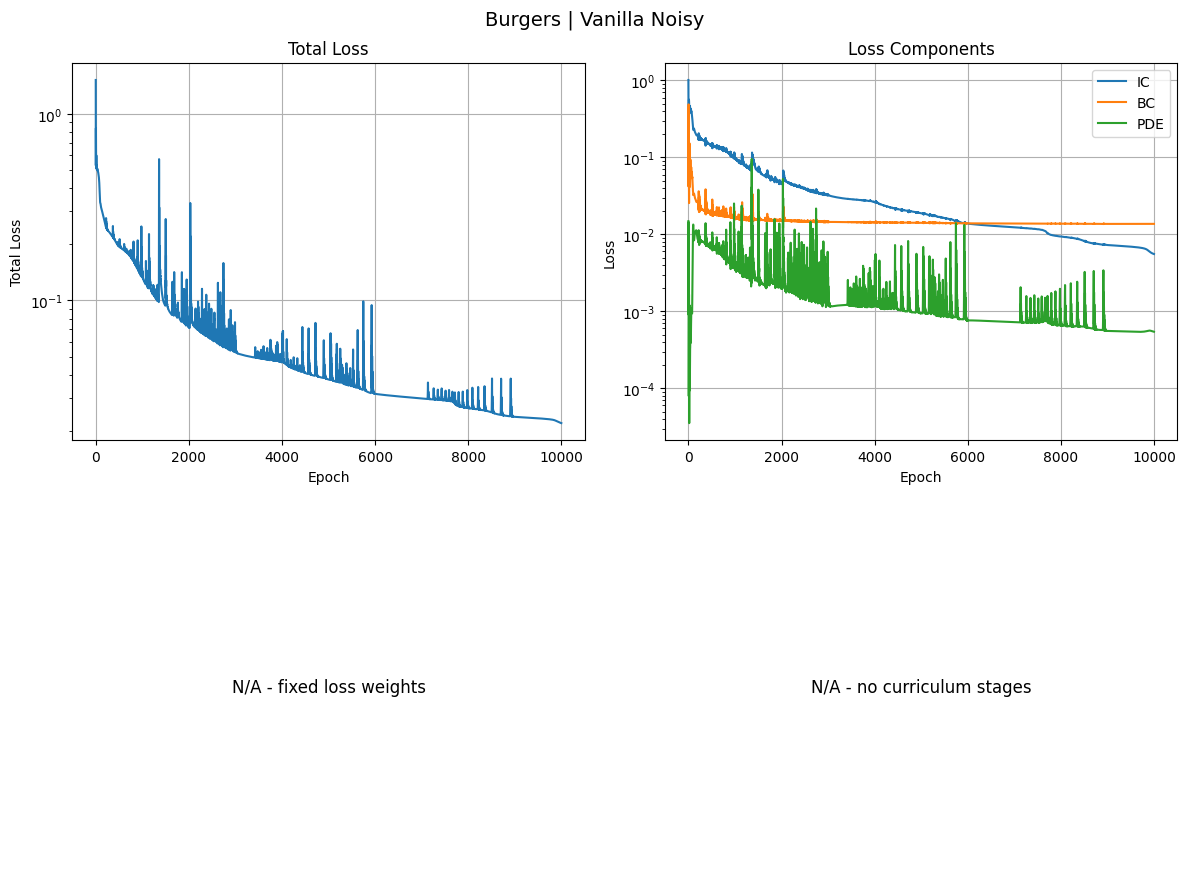

Saved: ../figures/burgers/vanilla_noisy_training.png
Saved: ../figures/burgers/vanilla_noisy_training.csv


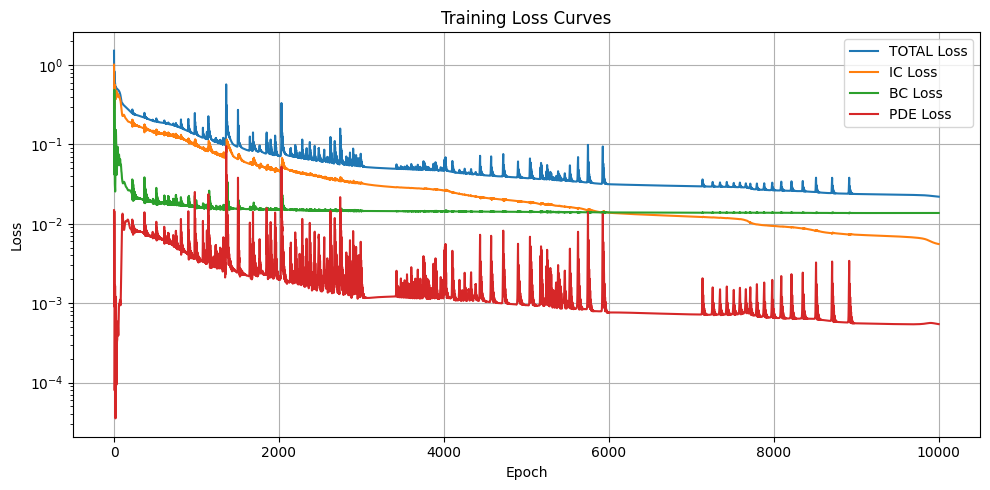

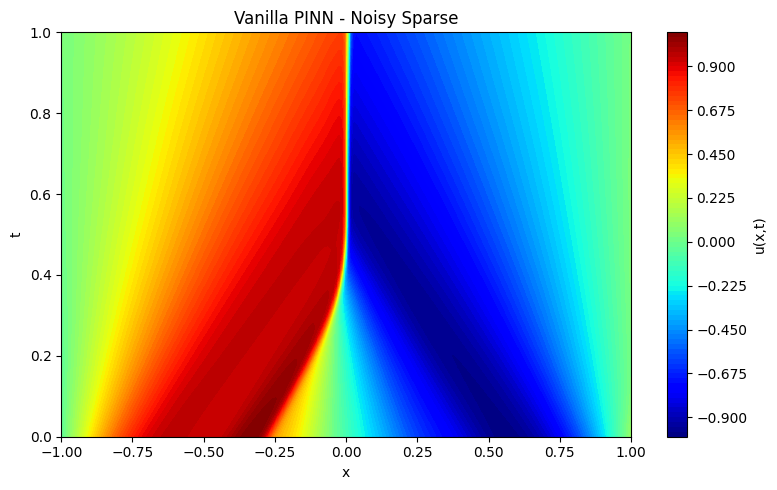

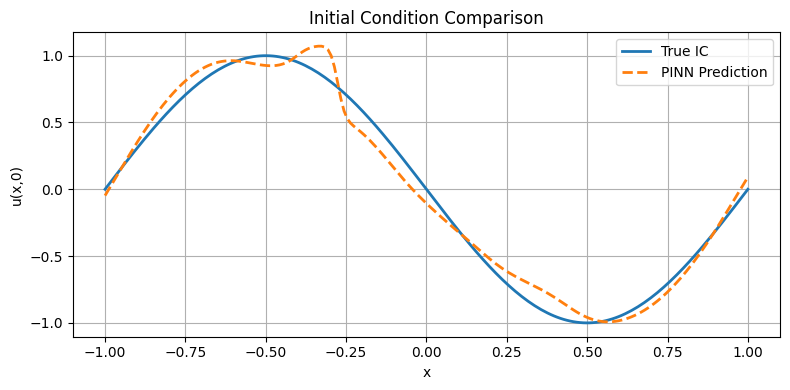

Saved: ../results/burgers/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Burgers | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
vanilla_noisy.plot_initial_condition_comparison(gen)
save_history(h_vn, RESULTS + 'vanilla_noisy_history.npy')

## Section 5 - Experiment 3: AC-PINN, Clean Dense

[Burgers | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.635501 | IC: 0.484916 | BC: 0.031775 | PDE: 0.023762 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.000586 | IC: 0.000186 | BC: 0.000050 | PDE: 0.000014 | lam=(1.45,3.57,10.00)


[Burgers | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.000421 | IC: 0.000012 | BC: 0.000034 | PDE: 0.000092 | lam=(10.00,1.72,2.63)


[Burgers | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.000093 | IC: 0.000004 | BC: 0.000008 | PDE: 0.000011 | lam=(2.12,2.82,5.74)


[Burgers | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.000054 | IC: 0.000002 | BC: 0.000005 | PDE: 0.000006 | lam=(3.09,1.97,5.93)


...

[Burgers | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.003578 | IC: 0.000478 | BC: 0.001472 | PDE: 0.000062 | lam=(0.71,2.19,0.10)


[Burgers | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000036 | IC: 0.000005 | BC: 0.000004 | PDE: 0.000016 | lam=(0.55,0.51,1.94)


[Burgers | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.696460 | IC: 0.235357 | BC: 0.002172 | PDE: 0.001191 | lam=(2.96,0.10,0.10)


[Burgers | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.748337 | IC: 0.000710 | BC: 0.000392 | PDE: 0.250506 | lam=(0.10,0.10,2.99)



AC-PINN training complete in 170.48s


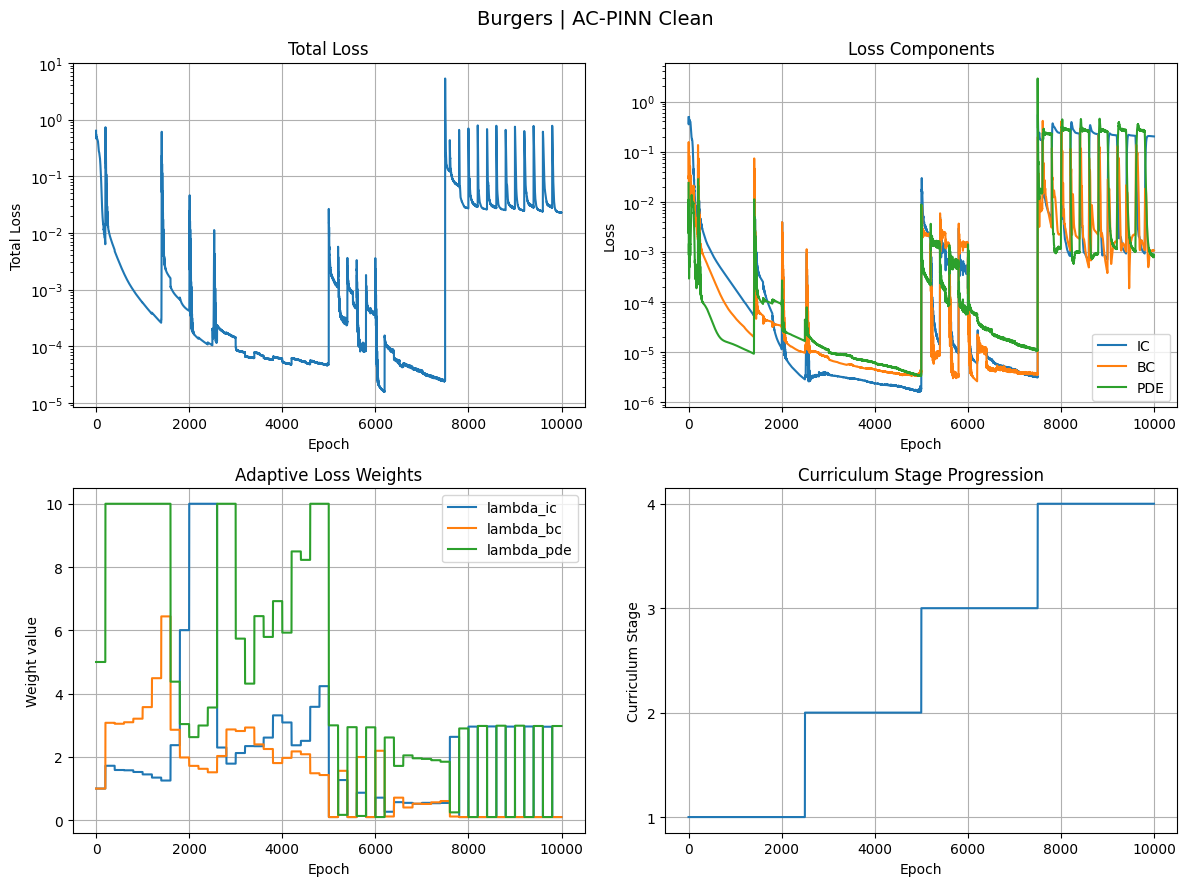

Saved: ../figures/burgers/acpinn_clean_training.png
Saved: ../figures/burgers/acpinn_clean_training.csv


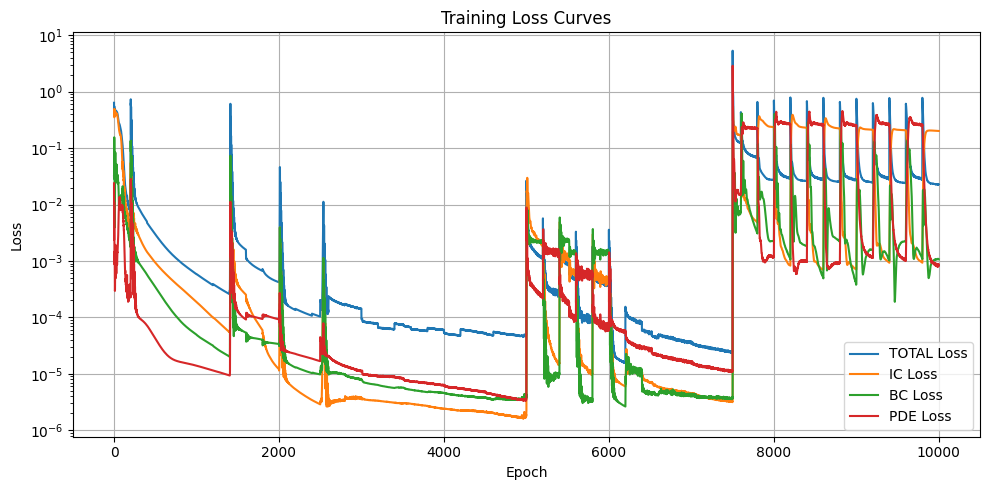

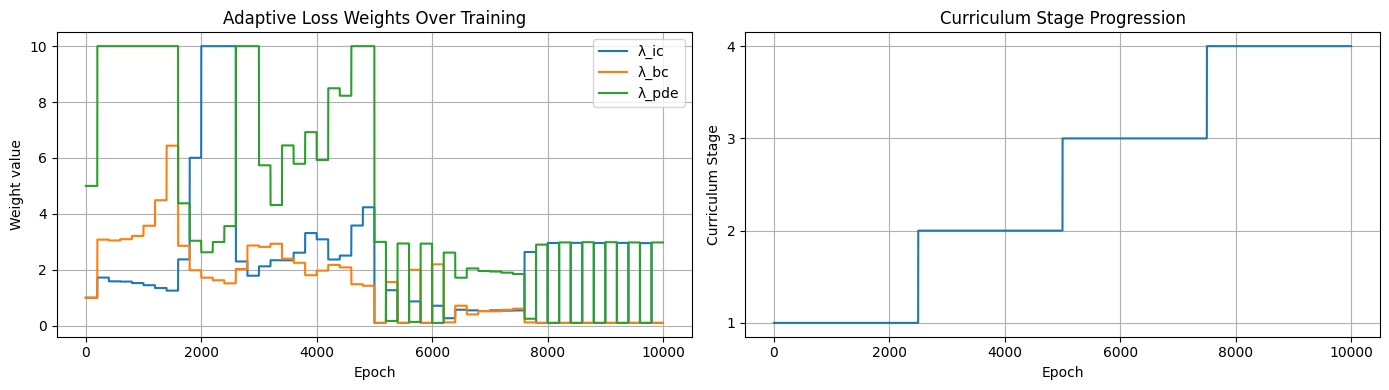

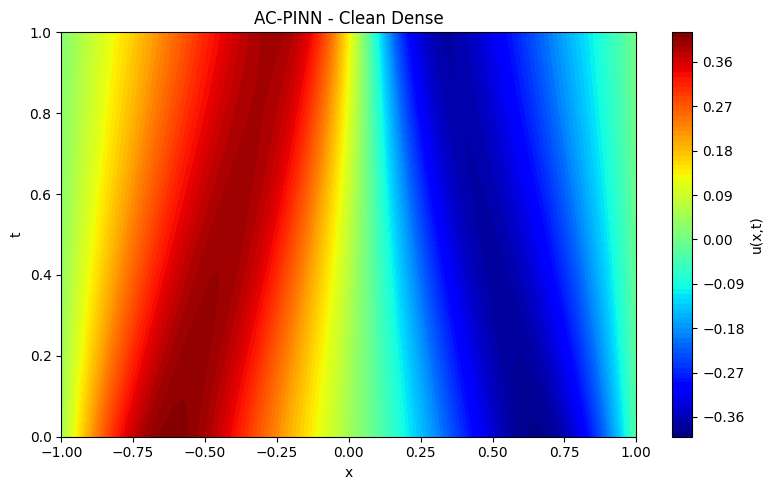

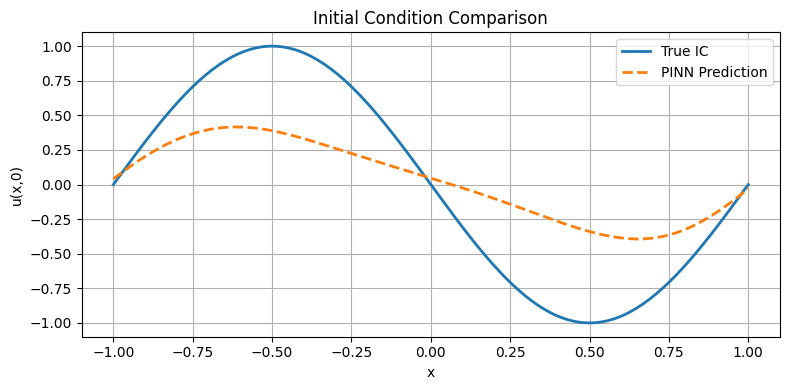

Saved: ../results/burgers/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Burgers | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS + 'ac_clean_history.npy')

## Section 6 - Experiment 4: AC-PINN, Noisy Sparse

[Burgers | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.966934 | IC: 0.587075 | BC: 0.043600 | PDE: 0.067252 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.054857 | IC: 0.007883 | BC: 0.012851 | PDE: 0.000444 | lam=(3.19,2.16,4.49)


[Burgers | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.060267 | IC: 0.004335 | BC: 0.012612 | PDE: 0.000312 | lam=(10.00,1.09,10.00)


[Burgers | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.035567 | IC: 0.003201 | BC: 0.010363 | PDE: 0.000245 | lam=(5.93,1.39,8.86)


[Burgers | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.038576 | IC: 0.002475 | BC: 0.008775 | PDE: 0.000177 | lam=(10.00,1.51,3.45)


...

[Burgers | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.018867 | IC: 0.001807 | BC: 0.008405 | PDE: 0.002696 | lam=(0.42,1.95,0.63)


[Burgers | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.018098 | IC: 0.001371 | BC: 0.007810 | PDE: 0.001748 | lam=(0.38,2.14,0.48)


[Burgers | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.316318 | IC: 0.126331 | BC: 0.016829 | PDE: 0.012330 | lam=(2.44,0.32,0.24)


[Burgers | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.759172 | IC: 0.005752 | BC: 0.016273 | PDE: 0.272343 | lam=(0.10,0.17,2.78)



AC-PINN training complete in 142.72s


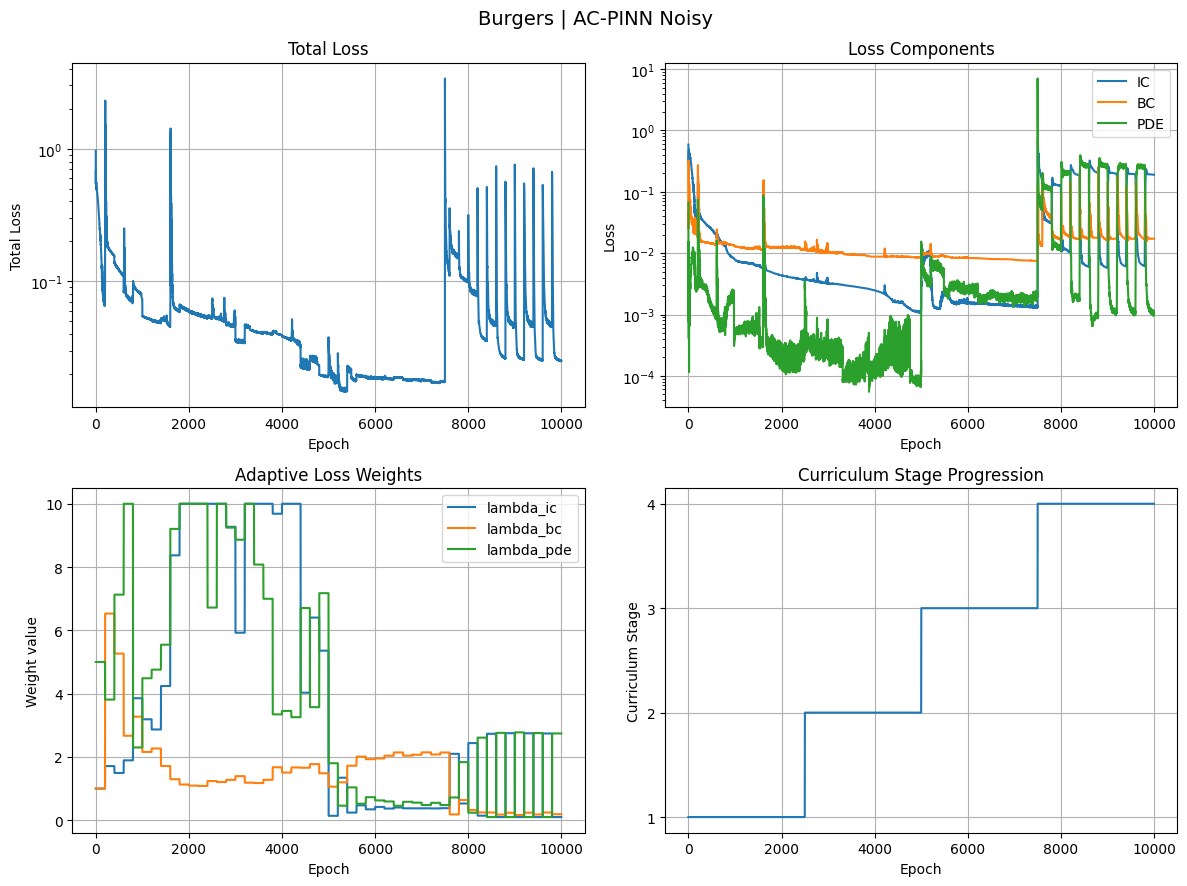

Saved: ../figures/burgers/acpinn_noisy_training.png
Saved: ../figures/burgers/acpinn_noisy_training.csv


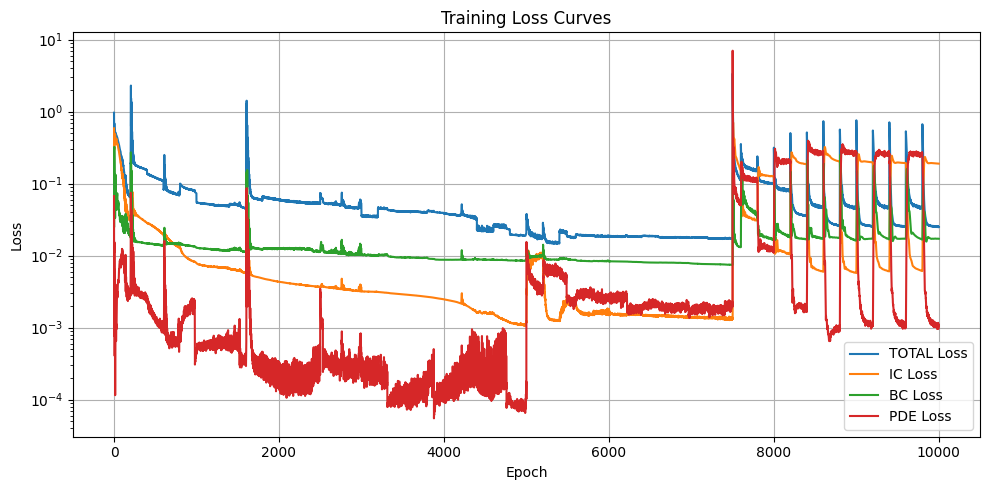

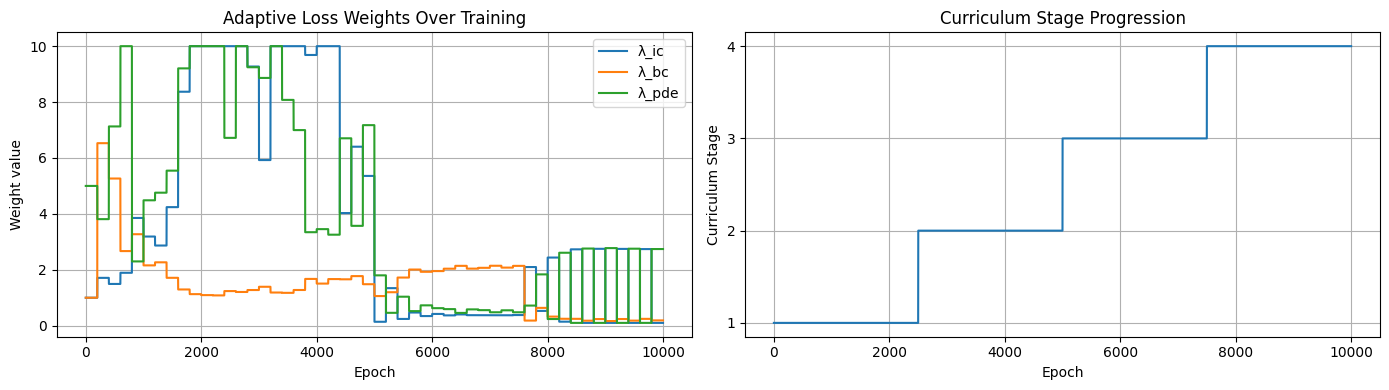

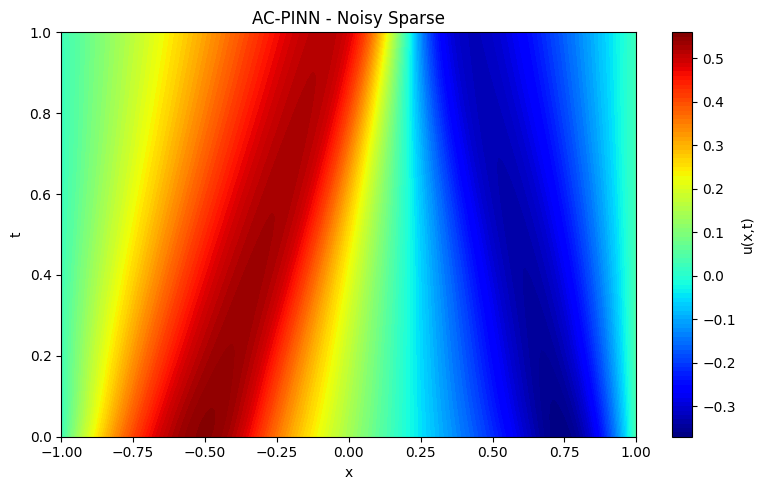

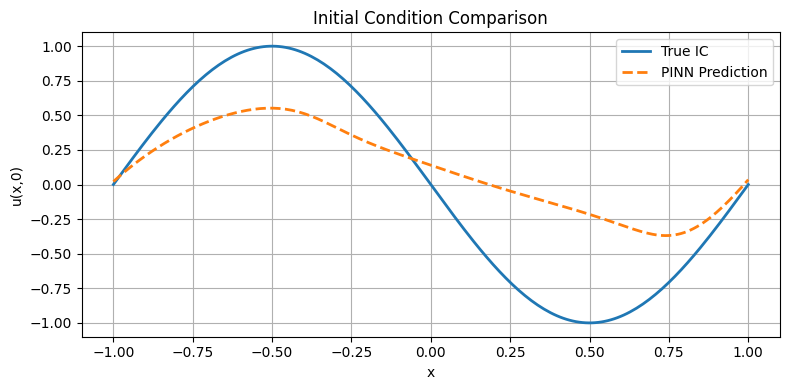

Saved: ../results/burgers/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Burgers | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
ac_noisy.plot_initial_condition_comparison(gen)
save_history(h_an, RESULTS + 'ac_noisy_history.npy')

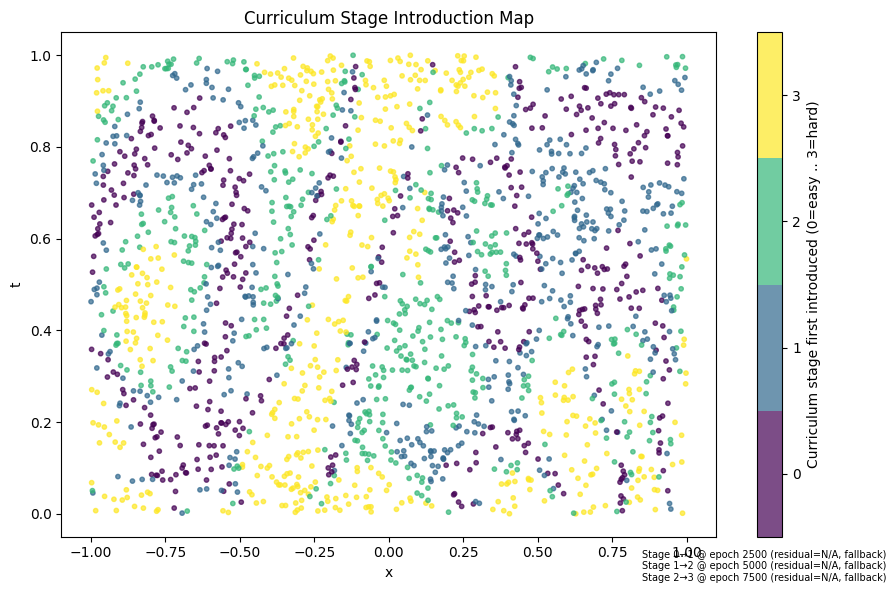

Saved: ../figures/burgers/curriculum_stages_noisy.png


In [8]:
ac_noisy.plot_curriculum_stages(
    h_an, data_noisy_sparse, FIGURES+'curriculum_stages_noisy.png'
)


## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.203272   1.585767   0.030469   0.123623
  Vanilla (noisy)             0.109231   0.694569   0.037483   0.066430
  AC-PINN (clean)             0.656507   0.993025   0.296556   0.399264
  AC-PINN (noisy)             0.694011   1.169843   0.297869   0.422073


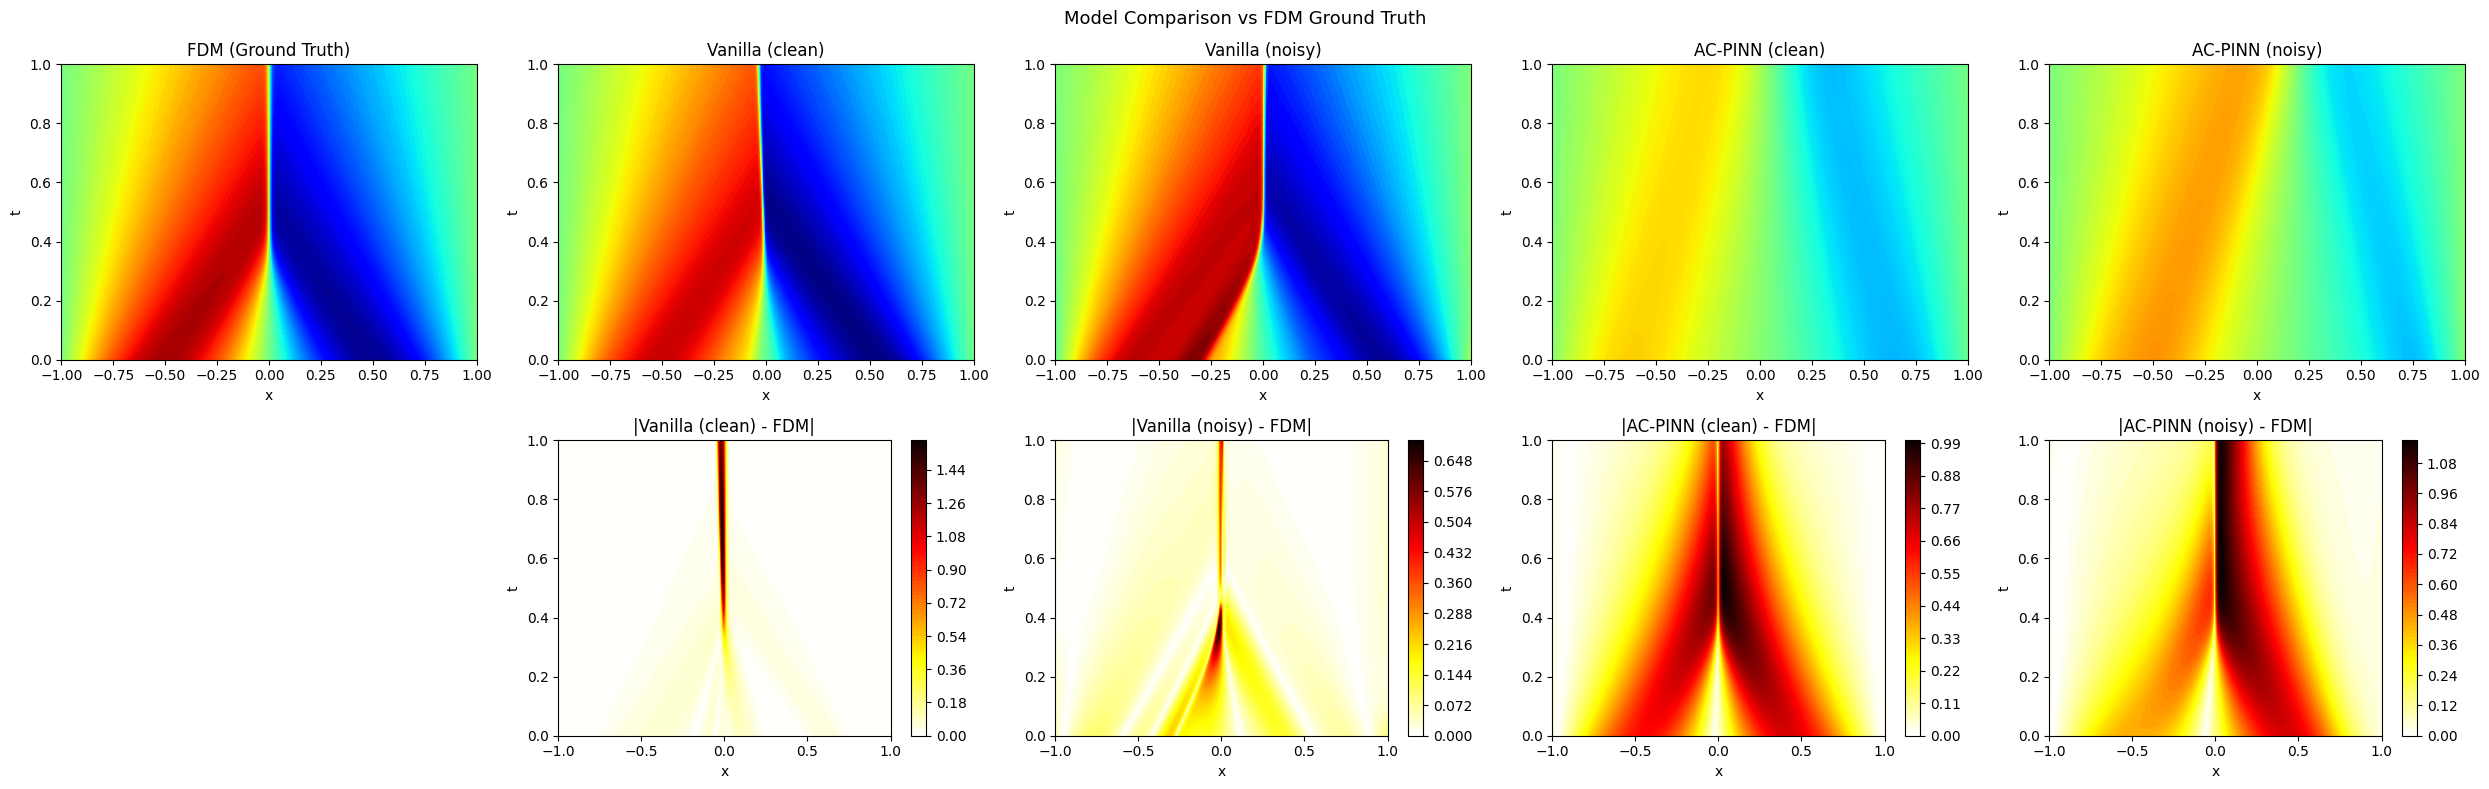

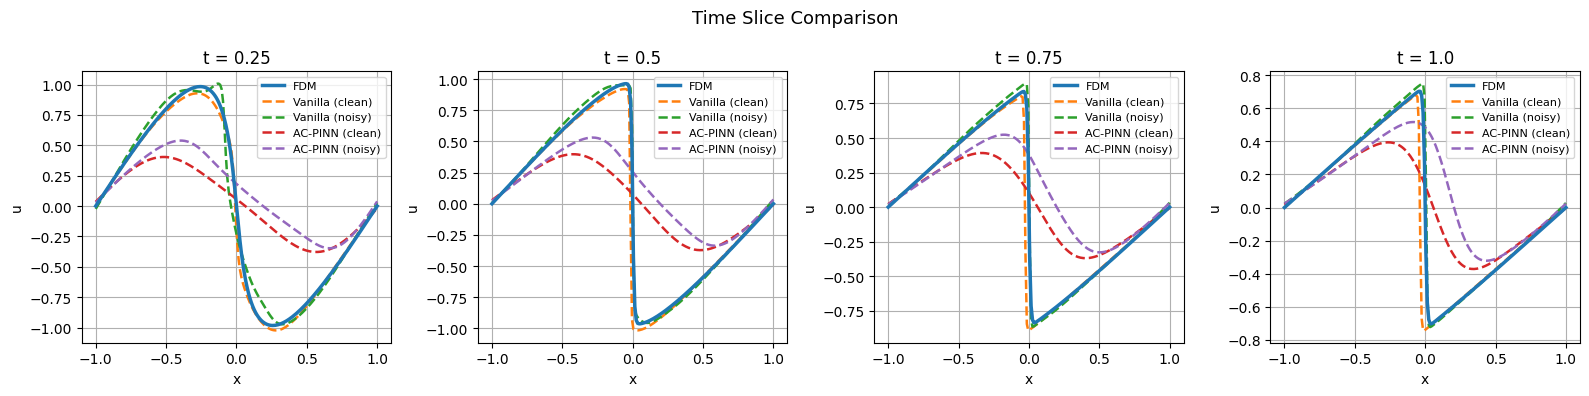

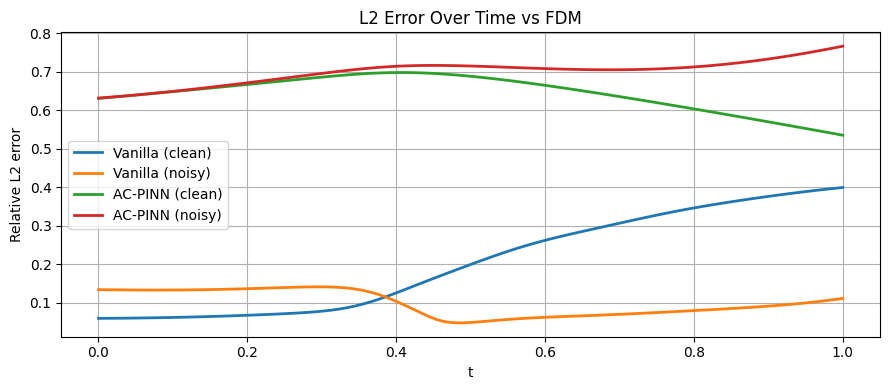

Saved: ../results/burgers/benchmark_metrics.npy
Burgers experiments complete. Results saved.


In [9]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)',  vanilla_clean)
bench.add('Vanilla (noisy)',  vanilla_noisy)
bench.add('AC-PINN (clean)',  ac_clean)
bench.add('AC-PINN (noisy)',  ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Burgers experiments complete. Results saved.')

## Section 8 - Noise Level Study (ε = 0.05, 0.1, 0.2)
AC-PINN vs Vanilla under increasing noise.

In [10]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- Noise level ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)

    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)

    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)

    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()

save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Noise study complete.')


--- Noise level ε=0.05 ---
[Epoch     0/5000] Total: 0.442944 | IC: 0.405624 | BC: 0.022518 | PDE: 0.002960


[Epoch  2500/5000] Total: 0.080660 | IC: 0.056252 | BC: 0.005293 | PDE: 0.003823



Training complete in 65.50s
[Epoch     0/5000] Stage 1/4 | Total: 0.503655 | IC: 0.492336 | BC: 0.011243 | PDE: 0.000015 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.068534 | IC: 0.002283 | BC: 0.004811 | PDE: 0.019776 | lam=(7.30,2.97,1.90)



AC-PINN training complete in 72.24s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.085577   0.236372   0.032836   0.052045
  AC-PINN ε=0.05              0.304991   0.864311   0.113221   0.185485

--- Noise level ε=0.1 ---
[Epoch     0/5000] Total: 0.502546 | IC: 0.402569 | BC: 0.081432 | PDE: 0.003709


...


AC-PINN training complete in 71.81s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.288464   1.655500   0.053298   0.175433
  AC-PINN ε=0.1               0.234239   0.763951   0.082860   0.142456

--- Noise level ε=0.2 ---
[Epoch     0/5000] Total: 0.586658 | IC: 0.493764 | BC: 0.088474 | PDE: 0.000884


[Epoch  2500/5000] Total: 0.182681 | IC: 0.088465 | BC: 0.084306 | PDE: 0.001982



Training complete in 65.12s
[Epoch     0/5000] Stage 1/4 | Total: 0.572231 | IC: 0.369654 | BC: 0.202065 | PDE: 0.000102 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.500748 | IC: 0.033383 | BC: 0.070118 | PDE: 0.023770 | lam=(8.89,1.58,3.92)



AC-PINN training complete in 72.13s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.499885   1.702175   0.124035   0.304012
  AC-PINN ε=0.2               0.340858   0.869739   0.127097   0.207298
Saved: ../results/burgers/noise_study_metrics.npy
Noise study complete.
